In [1]:
#Load and inspect
import pandas as pd


df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(df.shape)
df.info()
df['Attrition'].value_counts(normalize=True)

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

,proportion
Attrition,
No,0.838776
Yes,0.161224


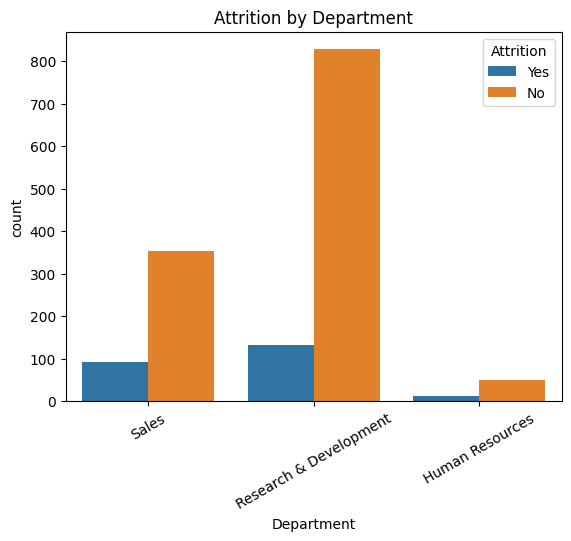

In [2]:
#EDA — find what's actually driving attrition
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Department', hue='Attrition')
plt.xticks(rotation=30)
plt.title('Attrition by Department')
plt.show()

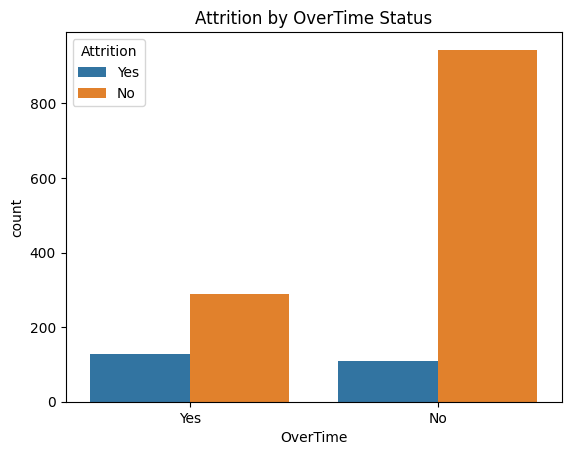

In [3]:
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('Attrition by OverTime Status')
plt.show()

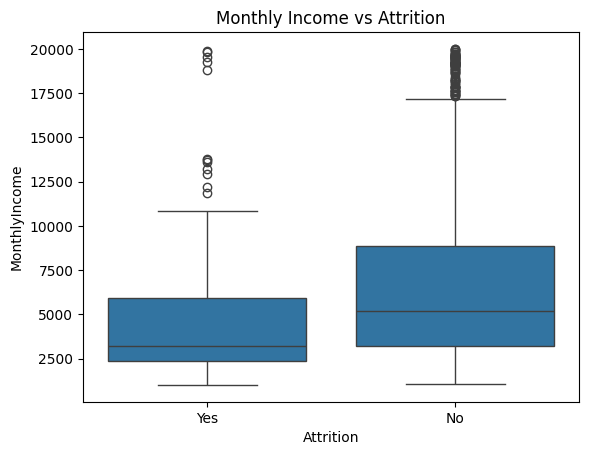

In [4]:
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('Monthly Income vs Attrition')
plt.show()

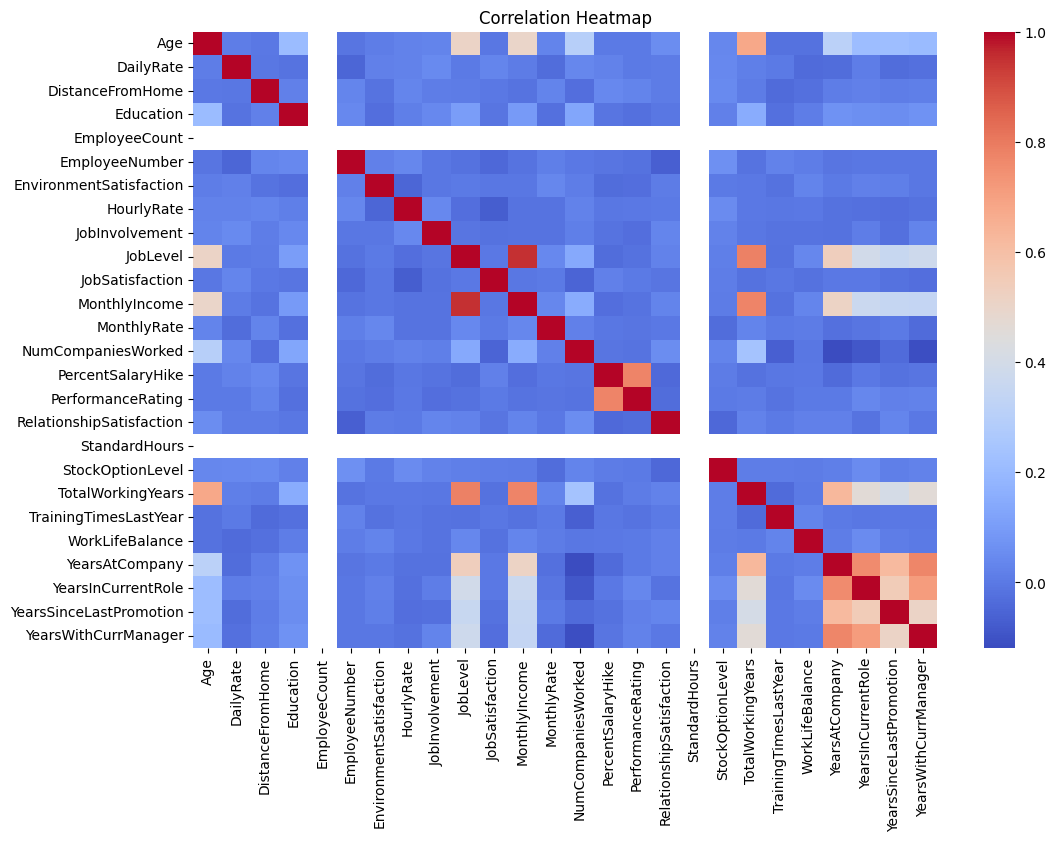

In [5]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

In [6]:
#Clean and engineer features for the dashboard
# Check for constant columns first, then drop
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print('Constant columns to drop:', constant_cols)
df = df.drop(columns=constant_cols)

# Bucket Age and YearsAtCompany for cleaner Power BI visuals
df['AgeBucket'] = pd.cut(df['Age'], bins=[17,25,35,45,60],
                          labels=['18-25','26-35','36-45','46-60'])
df['TenureBucket'] = pd.cut(df['YearsAtCompany'], bins=[-1,2,5,10,100],
                             labels=['0-2','3-5','6-10','10+'])

# Numeric flag for DAX aggregation
df['AttritionFlag'] = (df['Attrition'] == 'Yes').astype(int)

df.head()

Constant columns to drop: ['EmployeeCount', 'Over18', 'StandardHours']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeBucket,TenureBucket,AttritionFlag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,8,0,1,6,4,0,5,36-45,6-10,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,10,3,3,10,7,1,7,46-60,6-10,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,7,3,3,0,0,0,0,36-45,0-2,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,8,3,3,8,7,3,0,26-35,6-10,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,6,3,3,2,2,2,2,26-35,0-2,0


In [7]:
#Export cleaned data
from google.colab import files
df.to_csv('hr_attrition_cleaned.csv', index=False)
files.download('hr_attrition_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>